# 02 Analysis - Driving Data

# Setup

## Bootstrap, Imports and Full data load + Validaiton

In [1]:
# ==============================
# Session Starter
# ==============================
import os, pathlib, sys, pandas as pd

# Ensure CWD is repo root
if pathlib.Path().resolve().name == "notebooks":
    os.chdir("..")
print("CWD:", os.getcwd())
print("Python:", sys.version.split()[0], "| pandas:", pd.__version__)

# Auto-reload src/ modules
%load_ext autoreload
%autoreload 2

# Project imports
from pathlib import Path
from src.ingest import load_journey_event_with_config
from src.validate import validate_journey_event
from src.utils import guess_header_row

# Config (full dataset)
CFG_FULL = {
    "sheet_name": "Journey Event",
    "header": "auto",
    "usecols": "B:BC",
    "date_cols": ["RTC Date Time","GPS Date Time","Event Time Stamp"],
    "dayfirst": True,
    "keep_cols": [
        "Policy Number","Voucher ID","Journey ID",
        "Event Time Stamp","GPS Date Time",
        "Latitude","Longitude","Street",
        "Event Type","Horizontal Speed","Road Speed Limit",
        "Accumulated Trip Distance","Accumulated Trip Idle Time","Accumulated Trip Run Time",
    ],
    "validate": True,
}
file_full = "data/raw/TMT Data Full.xlsx"

# Load and validate
df_events = load_journey_event_with_config(
    xlsx_path=file_full,
    cfg=CFG_FULL,
    write_interim=Path("data/interim/journey_event_keep_full.parquet")
)
validate_journey_event(df_events)
print("✅ events schema ok:", df_events.shape)

# Also load the 1Hz parquet (canonical time series)
import pyarrow.parquet as pq
schema_cols = pq.ParquetFile("data/interim/journey_event_1hz.parquet").schema.names
cand = [
    "EventTimestamp","GPS Date Time","Event Time Stamp",
    "GpsSpeedMph","GpsSpeed","RoadSpeedLimitMph","Road Speed Limit",
    "Latitude","Longitude","Journey ID","source_sheet"
]
use = [c for c in cand if c in schema_cols]
df_1hz = pd.read_parquet("data/interim/journey_event_1hz.parquet", columns=use)
df_1hz["when"]  = pd.to_datetime(df_1hz.get("EventTimestamp", df_1hz.get("GPS Date Time")), errors="coerce")
df_1hz["speed"] = pd.to_numeric(df_1hz.get("GpsSpeedMph", df_1hz.get("GpsSpeed")), errors="coerce")
df_1hz["limit"] = pd.to_numeric(df_1hz.get("RoadSpeedLimitMph", df_1hz.get("Road Speed Limit")), errors="coerce")
df_1hz = df_1hz.dropna(subset=["when","speed","limit"]).sort_values("when")
print("✅ 1Hz stream ok:", df_1hz.shape)

CWD: /Users/abdulrahmanaboluhom/Documents/GitHub/Projects/indepth-driving-data-analysis
Python: 3.9.6 | pandas: 2.3.1
✅ events schema ok: (23405, 14)
✅ 1Hz stream ok: (1247282, 11)


# Analysis

## A. Speeding

In [16]:
# Must exist: df_1hz with these core columns
need = {"when","speed","limit"}
print("Has df_1hz?", "df_1hz" in globals())
if "df_1hz" in globals():
    print("Columns on df_1hz:", list(df_1hz.columns)[:12], "…")
    print("Has core cols?", need.issubset(df_1hz.columns))

Has df_1hz? True
Columns on df_1hz: ['EventTimestamp', 'GpsSpeedMph', 'GpsSpeed', 'RoadSpeedLimitMph', 'Latitude', 'Longitude', 'Journey ID', 'source_sheet', 'when', 'speed', 'limit'] …
Has core cols? True


In [17]:
# Minimal columns (lat/lon optional for later maps)
cols = [c for c in ["when","speed","limit","Latitude","Longitude","Journey ID"] if c in df_1hz.columns]
dfv = (df_1hz[cols]
       .dropna(subset=["when","speed","limit"])
       .query("limit > 0")                 # drop zeros/bogus limits
       .sort_values("when")
       .reset_index(drop=True))

# Flags
dfv["over"] = dfv["speed"] > dfv["limit"]
dfv["overspeed_amt"] = dfv["speed"] - dfv["limit"]

print(dfv.shape)
dfv.head(3)

(1214601, 8)


,when,speed,limit,Latitude,Longitude,Journey ID,over,overspeed_amt
0,2024-11-28 16:16:04,0.000,20.0,53.782589,-1.82126,230797620241128161604,False,-20.000
1,2024-11-28 16:16:05,0.621,20.0,53.782612,-1.82129,230797620241128161604,False,-19.379
2,2024-11-28 16:16:06,0.621,20.0,53.782612,-1.82130,230797620241128161604,False,-19.379


In [18]:
total = len(dfv)
speeding = int(dfv["over"].sum())
rate = 100 * speeding / total if total else 0
print(f"Overall speeding rate: {rate:.2f}%  ({speeding:,}/{total:,})")
print("Max overspeed:", round(dfv.loc[dfv["over"], "overspeed_amt"].max(), 2) if speeding else 0)

Overall speeding rate: 1.89%  (22,954/1,214,601)
Max overspeed: 64.59


In [19]:
rate_by_hour = (dfv.groupby(dfv["when"].dt.hour)["over"].mean()
                .reindex(range(24), fill_value=0))
counts_by_hour = (dfv.groupby(dfv["when"].dt.hour)["over"].size()
                  .reindex(range(24), fill_value=0))

print("Speeding % by hour:", (rate_by_hour*100).round(1).to_dict())
print("Counts by hour:", counts_by_hour.to_dict())

Speeding % by hour: {0: 1.7, 1: 1.3, 2: 1.5, 3: 2.6, 4: 1.0, 5: 2.9, 6: 1.2, 7: 1.3, 8: 1.8, 9: 2.5, 10: 2.1, 11: 1.9, 12: 2.3, 13: 2.1, 14: 1.5, 15: 1.4, 16: 1.5, 17: 1.6, 18: 1.7, 19: 3.1, 20: 2.5, 21: 1.2, 22: 1.8, 23: 2.1}
Counts by hour: {0: 6908, 1: 3149, 2: 5356, 3: 2993, 4: 7827, 5: 10239, 6: 51805, 7: 32657, 8: 24427, 9: 35208, 10: 52189, 11: 42603, 12: 56442, 13: 69260, 14: 84433, 15: 97990, 16: 127887, 17: 120081, 18: 89725, 19: 108902, 20: 108904, 21: 47832, 22: 20801, 23: 6983}


In [20]:
if "Journey ID" in dfv.columns:
    # How many points per trip? (use this to see if filtering is too strict)
    pts_per_trip = dfv["Journey ID"].value_counts()
    print("Trips:", len(pts_per_trip), "| median pts/trip:", int(pts_per_trip.median()))

    MIN_TRIP_POINTS = 120  # tweak later
    keep_trips = pts_per_trip[pts_per_trip >= MIN_TRIP_POINTS].index
    dfv_big = dfv[dfv["Journey ID"].isin(keep_trips)]

    if len(dfv_big):
        trip_summary = (dfv_big.groupby("Journey ID")
                        .agg(events=("over","size"),
                             speeding=("over","sum"),
                             speeding_pct=("over","mean"),
                             max_overspeed=("overspeed_amt","max"))
                        .sort_values(["speeding_pct","max_overspeed"], ascending=[False, False]))
        print("trip_summary shape:", trip_summary.shape)
        display(trip_summary.head(10))
    else:
        print("No trips meet MIN_TRIP_POINTS yet — lower the threshold and retry.")
else:
    print("No 'Journey ID' column in dfv — skipping trip-level for now.")

Trips: 1410 | median pts/trip: 620
trip_summary shape: (1188, 4)


,events,speeding,speeding_pct,max_overspeed
Journey ID,,,,
230797620250628090305,351,87,0.247863,25.981
230797620250725190144,4323,1046,0.241962,57.671
230797620250709175054,532,99,0.186090,4.233
230797620250614073051,366,60,0.163934,14.175
230797620250718110450,581,87,0.149742,4.797
230797620250607141452,216,32,0.148148,4.233
230797620250714235809,276,37,0.134058,7.962
230797620250601151445,262,35,0.133588,5.418
230797620250630120926,1657,214,0.129149,34.623


In [21]:
if "trip_summary" in globals() and len(trip_summary):
    worst_trip_id = trip_summary.index[0]
    print("Worst trip:", worst_trip_id)
    sample = (dfv[dfv["Journey ID"] == worst_trip_id]
              [["when","speed","limit","overspeed_amt","Latitude","Longitude"]]
              .sort_values("when")
              .head(20))
    display(sample)
else:
    print("No trip_summary available — run S4 successfully first.")

Worst trip: 230797620250628090305


,when,speed,limit,overspeed_amt,Latitude,Longitude
925016,2025-06-28 09:03:12,0.000,30.0,-30.000,53.777519,-1.76080
925017,2025-06-28 09:03:13,0.000,30.0,-30.000,53.777550,-1.76082
925018,2025-06-28 09:03:14,0.000,30.0,-30.000,53.777550,-1.76085
925019,2025-06-28 09:03:15,0.621,30.0,-29.379,53.777851,-1.76100
925020,2025-06-28 09:03:16,0.621,30.0,-29.379,53.777908,-1.76107
925021,2025-06-28 09:03:17,1.243,30.0,-28.757,53.777920,-1.76112
925022,2025-06-28 09:03:18,1.243,30.0,-28.757,53.777962,-1.76115
925023,2025-06-28 09:03:19,1.243,30.0,-28.757,53.777981,-1.76117
925024,2025-06-28 09:03:20,1.243,30.0,-28.757,53.777969,-1.76124
925025,2025-06-28 09:03:23,0.621,30.0,-29.379,53.777901,-1.76115


## Episodes for speeding (mins,hours, etc)

In [28]:
# STEP 1 (fixed): events -> episodes (keep Journey ID)
dfv = dfv.sort_values(["Journey ID","when"]).copy()
dfv["is_over"]   = dfv["speed"] > dfv["limit"]
dfv["ep_change"] = (
    (dfv["is_over"] != dfv["is_over"].shift()) |
    (dfv["Journey ID"] != dfv["Journey ID"].shift())
).cumsum()

episodes = (
    dfv[dfv["is_over"]]
      .groupby(["Journey ID","ep_change"])
      .agg(
          start=("when","min"),
          end=("when","max"),
          dur_s=("when", lambda x: (x.max()-x.min()).total_seconds()),
          max_over=("overspeed_amt","max"),
          n_points=("when","count"),
          lat=("Latitude","mean"),
          lon=("Longitude","mean"),
      )
      .reset_index()   # <-- keep Journey ID
)

episodes["dur_min"] = episodes["dur_s"] / 60
print(episodes.head(3))
print("episodes shape:", episodes.shape)

              Journey ID  ep_change               start                 end  \
0  230797620241128211313          4 2024-11-28 21:18:02 2024-11-28 21:18:02   
1  230797620241129093202          7 2024-11-29 09:49:22 2024-11-29 09:49:25   
2  230797620241129093202          9 2024-11-29 09:55:35 2024-11-29 09:55:35   

   dur_s  max_over  n_points        lat       lon  dur_min  
0    0.0     1.748         1  53.791439 -1.778650     0.00  
1    3.0     2.311         4  53.774502 -1.775412     0.05  
2    0.0    22.817         1  53.751099 -1.739670     0.00  
episodes shape: (6619, 10)


In [29]:
# STEP 2: per-trip summary now works
trip_summary = (
    episodes.groupby("Journey ID", as_index=False)
            .agg(
                n_episodes=("dur_s","count"),
                total_s=("dur_s","sum"),
                max_episode_s=("dur_s","max"),
                max_over=("max_over","max"),
            )
)
trip_summary["total_min"] = trip_summary["total_s"] / 60
trip_summary = trip_summary.sort_values("total_min", ascending=False)
trip_summary.head(10)

,Journey ID,n_episodes,total_s,max_episode_s,max_over,total_min
795,230797620250725190144,167,884.0,51.0,57.671,14.733333
690,230797620250710171128,214,662.0,51.0,54.594,11.033333
710,230797620250713091145,121,288.0,45.0,63.972,4.800000
688,230797620250710102135,150,279.0,30.0,54.594,4.650000
565,230797620250611202449,40,225.0,34.0,17.904,3.750000
631,230797620250630120926,33,195.0,41.0,34.623,3.250000
793,230797620250725131451,60,187.0,44.0,45.865,3.116667
711,230797620250713190423,142,177.0,23.0,64.594,2.950000
576,230797620250614120057,63,147.0,20.0,30.331,2.450000
479,230797620250522190425,31,140.0,27.0,6.719,2.333333


In [30]:
worst_trip = trip_summary.iloc[0]["Journey ID"]

sub = dfv[dfv["Journey ID"] == worst_trip].copy()

m = folium.Map(location=[sub["Latitude"].mean(), sub["Longitude"].mean()],
               zoom_start=12, tiles="cartodbpositron")

# Full route line
folium.PolyLine(sub[["Latitude","Longitude"]].dropna().values,
                color="blue", weight=2).add_to(m)

# Mark speeding points
for _, row in sub[sub["is_over"]].iterrows():
    folium.CircleMarker(
        location=(row["Latitude"],row["Longitude"]),
        radius=3, color="red", fill=True, fill_opacity=0.5
    ).add_to(m)

m.save("outputs/worst_trip_speeding.html")
print("✓ saved outputs/worst_trip_speeding.html")

✓ saved outputs/worst_trip_speeding.html


In [31]:
# Saving

episodes.to_parquet("data/interim/overspeed_episodes.parquet", index=False)
print("saved: data/interim/overspeed_episodes.parquet", episodes.shape)

saved: data/interim/overspeed_episodes.parquet (6619, 10)


In [33]:
""" Next session breadcrumbs (short + concrete)
	1.	Load df_events, df_1hz; read overspeed_episodes.parquet.
	2.	Trip-level summary from episodes: total overspeed minutes, max over, count per trip.
	3.	Maps: route + episode markers for the worst 3 trips.
	4.	Start night driving (22:00–04:00): percent of time & episodes at night.
	5.	Begin accel/decel (derive a m/s² column; flag harsh ± thresholds)."""


' Next session breadcrumbs (short + concrete)\n\t1.\tLoad df_events, df_1hz; read overspeed_episodes.parquet.\n\t2.\tTrip-level summary from episodes: total overspeed minutes, max over, count per trip.\n\t3.\tMaps: route + episode markers for the worst 3 trips.\n\t4.\tStart night driving (22:00–04:00): percent of time & episodes at night.\n\t5.\tBegin accel/decel (derive a m/s² column; flag harsh ± thresholds).'

## Bogus Speeding Data

In [23]:
# Top N worst overspeed events
TOPN = 100
worst_events = (dfv[dfv["over"]]     # only speeding rows
                .sort_values("overspeed_amt", ascending=False)
                .head(TOPN)
                [["when","speed","limit","overspeed_amt","Latitude","Longitude"]])

print("Top", TOPN, "overspeed events")
display(worst_events)

Top 100 overspeed events


,when,speed,limit,overspeed_amt,Latitude,Longitude
1068812,2025-07-13 19:42:47,69.594,5.0,64.594,53.598110,-2.57252
1064089,2025-07-13 10:05:32,68.972,5.0,63.972,53.603409,-2.57552
1067995,2025-07-13 19:29:09,67.729,5.0,62.729,53.782440,-2.64932
1103814,2025-07-16 08:02:33,70.836,10.0,60.836,53.716492,-1.74562
1103816,2025-07-16 08:02:35,70.836,10.0,60.836,53.717060,-1.74547
...,...,...,...,...,...,...
1052047,2025-07-12 14:08:39,67.108,20.0,47.108,53.621380,-2.08169
520607,2025-04-03 11:28:55,67.108,20.0,47.108,53.759338,-1.60534
1038392,2025-07-10 19:19:30,77.050,30.0,47.050,53.665600,-1.53889
1034290,2025-07-10 18:10:14,56.545,10.0,46.545,52.879269,-1.55138


In [24]:
import folium

if not worst_events.empty:
    m = folium.Map(
        location=[worst_events["Latitude"].mean(), worst_events["Longitude"].mean()],
        zoom_start=11, tiles="cartodbpositron"
    )

    for _, row in worst_events.iterrows():
        folium.CircleMarker(
            location=(row["Latitude"], row["Longitude"]),
            radius=6,
            color="red", fill=True, fill_opacity=0.7,
            popup=f"{row['when']}<br>Speed={row['speed']:.1f} vs Limit={row['limit']:.1f}<br>Over={row['overspeed_amt']:.1f}"
        ).add_to(m)

    m.save("outputs/worst_events_map.html")
    print("✓ saved outputs/worst_events_map.html")
else:
    print("No overspeed events to map")

✓ saved outputs/worst_events_map.html


/Users/abdulrahmanaboluhom/Documents/GitHub/Projects/indepth-driving-data-analysis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## SQL Practice

In [2]:
# Connect + verify files

import duckdb, os, pathlib

PATH_EVENTS = "data/interim/journey_event_keep_full.parquet"
PATH_1HZ    = "data/interim/journey_event_1hz.parquet"

assert os.path.exists(PATH_EVENTS), f"Missing: {PATH_EVENTS}"
assert os.path.exists(PATH_1HZ),    f"Missing: {PATH_1HZ}"

pathlib.Path("data/interim").mkdir(parents=True, exist_ok=True)
con = duckdb.connect("data/interim/analysis.duckdb")
print("DB:", pathlib.Path("data/interim/analysis.duckdb").resolve())

DB: /Users/abdulrahmanaboluhom/Documents/GitHub/Projects/indepth-driving-data-analysis/data/interim/analysis.duckdb


In [3]:
cols_events = con.sql(f"SELECT * FROM read_parquet('{PATH_EVENTS}') LIMIT 0").df().columns.tolist()
cols_1hz    = con.sql(f"SELECT * FROM read_parquet('{PATH_1HZ}')    LIMIT 0").df().columns.tolist()
print("EVENTS cols:", cols_events[:15], "…")
print("1HZ cols   :", cols_1hz[:15], "…")

EVENTS cols: ['Policy Number', 'Voucher ID', 'Journey ID', 'Event Time Stamp', 'GPS Date Time', 'Latitude', 'Longitude', 'Street', 'Event Type', 'Horizontal Speed', 'Road Speed Limit', 'Accumulated Trip Distance', 'Accumulated Trip Idle Time', 'Accumulated Trip Run Time'] …
1HZ cols   : ['ServiceProviderCode', 'VoucherId', 'PolicyNumber', 'PlateNumber', 'DeviceSerialNumber', 'VIN', 'TrId', 'Journey ID', 'StartTime', 'EndTime', 'EventTimestamp', 'RecordType', 'EventType', 'Latitude', 'Longitude'] …


In [4]:
# Reuse cols_1hz from before; if not in memory, rebuild it:
# cols_1hz = con.sql(f"SELECT * FROM read_parquet('{PATH_1HZ}') LIMIT 0").df().columns.tolist()

[c for c in cols_1hz if "Speed" in c or "Limit" in c]

['RoadSpeedLimit', 'RoadSpeedLimitMph', 'GpsSpeed', 'GpsSpeedMph']

In [5]:
cols_1hz = con.sql(f"SELECT * FROM read_parquet('{PATH_1HZ}') LIMIT 0").df().columns.tolist()
print(cols_1hz)

['ServiceProviderCode', 'VoucherId', 'PolicyNumber', 'PlateNumber', 'DeviceSerialNumber', 'VIN', 'TrId', 'Journey ID', 'StartTime', 'EndTime', 'EventTimestamp', 'RecordType', 'EventType', 'Latitude', 'Longitude', 'GpsPoint', 'Altitude', 'Direction', 'Country', 'State', 'County', 'City', 'PostalCode', 'StreetName', 'StreetType', 'RoadSpeedLimit', 'RoadSpeedLimitMph', 'SatCount', 'DeltaGpsAccuracy', 'AvgAccX', 'AvgAccY', 'AvgAccZ', 'GpsSpeed', 'GpsSpeedMph', 'IsCalibrated', 'DeltaRunTime', 'DeltaValidGpsTime', 'DeltaDistance', 'JourneyEventId', 'AvgAngVelX', 'AvgAngVelY', 'AvgAngVelZ', 'MaxAbsAccXY', 'MaxAbsAccZ', 'HorizontalPrecision', 'ProductCode', 'ProductType', 'FirmwareVersion', 'FirmwareRevision', 'GatewayTimestamp', 'source_sheet']


In [6]:
def pick(cols, options):
    return next((c for c in options if c in cols), None)

jid_1hz  = pick(cols_1hz, ["Journey ID","JourneyID","TripId","TrId"])
lat_1    = pick(cols_1hz, ["Latitude"])
lon_1    = pick(cols_1hz, ["Longitude"])
ts_1     = pick(cols_1hz, ["EventTimestamp","StartTime","GatewayTimestamp"])
spd_1    = pick(cols_1hz, ["GpsSpeedMph","GpsSpeed","Horizontal Speed","speed"])
lim_1    = pick(cols_1hz, ["RoadSpeedLimitMph","Road Speed Limit","limit"])

assert all([jid_1hz, lat_1, lon_1, ts_1, spd_1, lim_1]), (jid_1hz, lat_1, lon_1, ts_1, spd_1, lim_1)

con.sql(f"""
CREATE OR REPLACE VIEW onehz AS
SELECT
  "{jid_1hz}"                                AS "Journey ID",
  {lat_1}                                    AS Latitude,
  {lon_1}                                    AS Longitude,
  TRY_CAST("{ts_1}" AS TIMESTAMP)            AS "when",
  TRY_CAST("{spd_1}" AS DOUBLE)              AS speed,
  TRY_CAST("{lim_1}" AS DOUBLE)              AS "limit"
FROM read_parquet('{PATH_1HZ}');
""")

In [ ]:
I want to find the number of times I drove at night


In [14]:
con.sql("""

SELECT "when", speed, "limit", "Journey ID", Latitude, Longitude
FROM onehz
WHERE "when" IS NOT NULL AND speed IS NOT NULL
ORDER BY speed DESC
LIMIT 1;

""").df()

,when,speed,limit,Journey ID,Latitude,Longitude
0,2025-07-10 19:23:40,87.613,71.0,230797620250710171128,53.722439,-1.52189


In [15]:
con.sql("""

SELECT "when",
       speed,
       "limit",
       (speed - "limit") AS overspeed,
       "Journey ID",
       Latitude, Longitude
FROM onehz
WHERE speed IS NOT NULL AND "limit" IS NOT NULL AND speed > "limit"
ORDER BY overspeed DESC
LIMIT 50;

""").df()

,when,speed,limit,overspeed,Journey ID,Latitude,Longitude
0,2025-06-26 15:07:48,80.157,0.0,80.157,230797620250626140622,53.915939,-1.17383
1,2025-07-14 10:54:10,79.536,0.0,79.536,230797620250714100231,53.916771,-1.17219
2,2025-07-14 10:54:22,79.536,0.0,79.536,230797620250714100231,53.917931,-1.16653
3,2025-07-14 10:54:11,78.914,0.0,78.914,230797620250714100231,53.916969,-1.17182
4,2025-07-14 10:54:21,78.914,0.0,78.914,230797620250714100231,53.917809,-1.16703
5,2025-07-14 10:54:20,78.914,0.0,78.914,230797620250714100231,53.917702,-1.16753
6,2025-06-26 15:07:47,78.293,0.0,78.293,230797620250626140622,53.915710,-1.17421
7,2025-07-14 10:54:23,78.293,0.0,78.293,230797620250714100231,53.918041,-1.16607
8,2025-07-14 10:54:09,78.293,0.0,78.293,230797620250714100231,53.916569,-1.17258
9,2025-07-14 10:54:12,77.671,0.0,77.671,230797620250714100231,53.917122,-1.17140


In [16]:
import matplotlib.pyplot as plt

def barh_top(df, x, y, n=20, title=""):
    d = df.nlargest(n, y)[[x,y]].iloc[::-1]
    d.plot(kind="barh", x=x, y=y, legend=False, figsize=(8, min(10, 0.4*len(d))))
    plt.title(title); plt.tight_layout(); plt.show()

def simple_bar(df, x, y, title=""):
    df.plot(kind="bar", x=x, y=y, legend=False, figsize=(8,4))
    plt.title(title); plt.tight_layout(); plt.show()

def line_over_time(df, x, y, title=""):
    df.plot(x=x, y=y, figsize=(9,4))
    plt.title(title); plt.tight_layout(); plt.show()

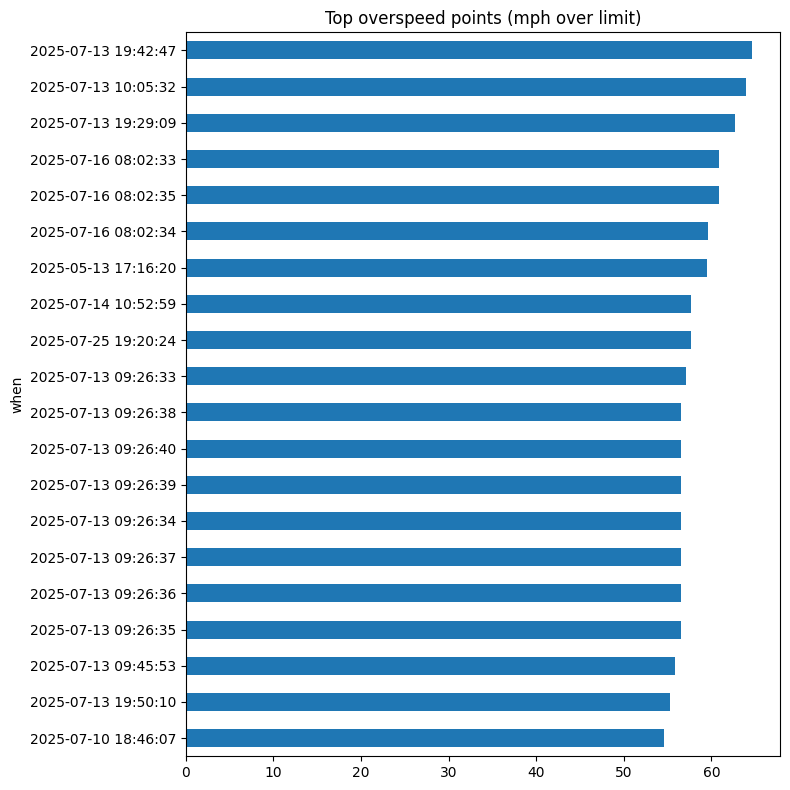

In [17]:
df = con.sql("""

SELECT
  "when", "Journey ID", Latitude, Longitude,
  speed, "limit",
  (speed - "limit") AS over
FROM onehz
WHERE "limit" > 0 AND speed > "limit"
ORDER BY over DESC
LIMIT 20;

""").df()
barh_top(df, x="when", y="over", n=20, title="Top overspeed points (mph over limit)")

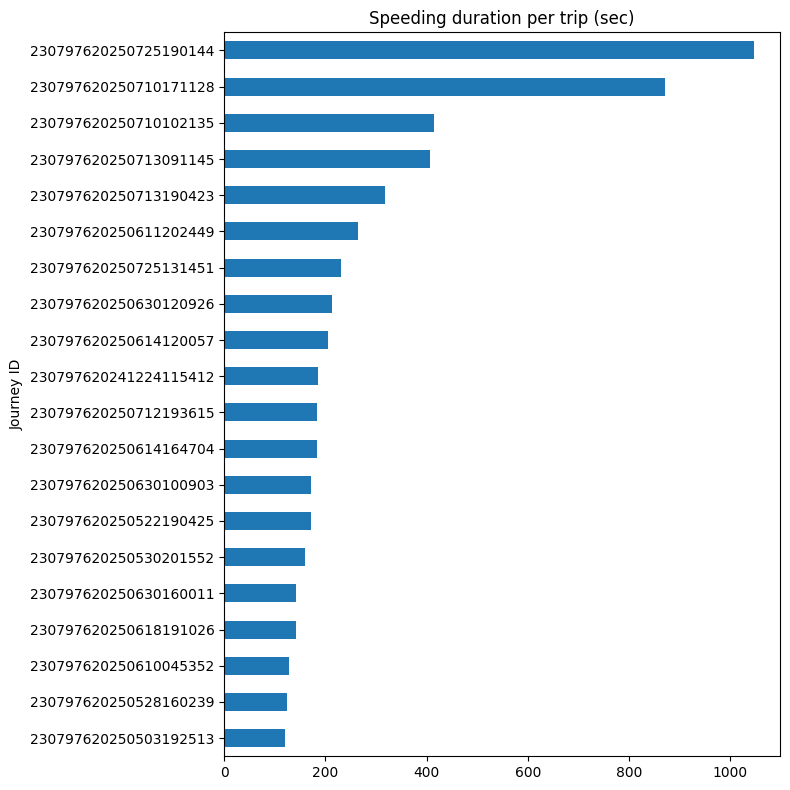

In [18]:
df = con.sql("""

WITH v AS (
  SELECT "Journey ID",
         CASE WHEN "limit" > 0 AND speed > "limit" THEN 1 ELSE 0 END AS over
  FROM onehz
)
SELECT "Journey ID",
       SUM(over)              AS seconds_speeding,
       COUNT(*)               AS seconds_total,
       100.0*AVG(over)        AS pct_speeding
FROM v
GROUP BY 1
ORDER BY seconds_speeding DESC
LIMIT 20;

""").df()

barh_top(df, x="Journey ID", y="seconds_speeding", title="Speeding duration per trip (sec)")

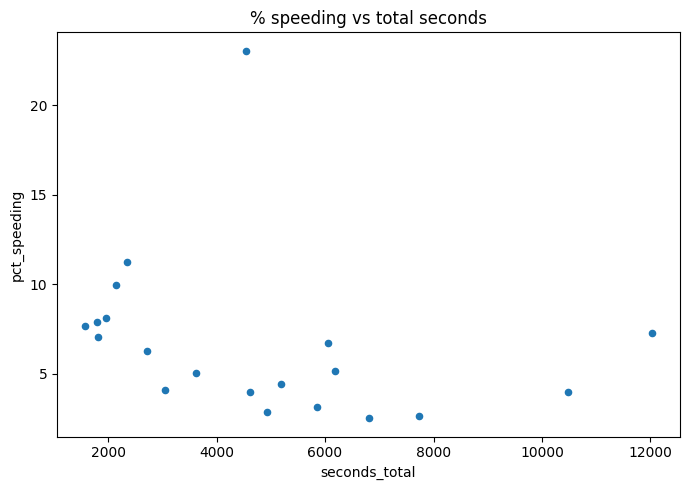

In [19]:
ax = df.plot.scatter(x="seconds_total", y="pct_speeding", figsize=(7,5))
plt.title("% speeding vs total seconds"); plt.tight_layout(); plt.show()

In [20]:
df = con.sql("""

SELECT STRFTIME("when",'%%w') AS dow_num,  -- 0=Sun … 6=Sat
       COUNT(*)                AS seconds
FROM onehz
GROUP BY 1
ORDER BY seconds DESC;

""").df()

In [21]:
!git add notebooks/02_analysis.ipynb docs/FINDINGS.md requirements.txt outputs/*.html
!git commit -m "chore: add analysis notebook; update findings + requirements; new maps"
!git push

[main cef48db] chore: add analysis notebook; update findings + requirements; new maps
 1 file changed, 36 insertions(+), 32 deletions(-)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 10 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 1.08 KiB | 367.00 KiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/abdulabolahom/indepth-driving-data-analysis.git
   b1c29ce..cef48db  main -> main


In [27]:
con.sql("""

CREATE OR REPLACE VIEW onehz_features AS
SELECT
  "Journey ID",
  Latitude, Longitude,
  "when",
  speed,
  "limit",
  speed * 1.60934                 AS speed_kmh,
  (speed > "limit")               AS over,
  GREATEST(speed - "limit", 0)    AS over_amt,
  EXTRACT(HOUR FROM "when")       AS hour,
  (EXTRACT(HOUR FROM "when") >= 22 OR EXTRACT(HOUR FROM "when") < 4) AS is_night
FROM onehz;
""")


In [28]:
con.sql('SELECT * FROM onehz_features LIMIT 5').df()

,Journey ID,Latitude,Longitude,when,speed,limit,speed_kmh,over,over_amt,hour,is_night
0,230797620241128161604,53.782589,-1.82126,2024-11-28 16:16:04,0.000,20.0,0.0000,False,0.0,16,False
1,230797620241128161604,53.782612,-1.82129,2024-11-28 16:16:05,0.621,20.0,0.9994,False,0.0,16,False
2,230797620241128161604,53.782612,-1.82130,2024-11-28 16:16:06,0.621,20.0,0.9994,False,0.0,16,False
3,230797620241128161604,53.782612,-1.82130,2024-11-28 16:16:07,0.000,20.0,0.0000,False,0.0,16,False
4,230797620241128161604,53.782612,-1.82133,2024-11-28 16:16:08,0.621,20.0,0.9994,False,0.0,16,False


In [29]:
con.sql("DROP TABLE IF EXISTS onehz_features_tbl;")
con.sql("CREATE TABLE onehz_features_tbl AS SELECT * FROM onehz_features;")
con.sql("SELECT COUNT(*) AS rows FROM onehz_features_tbl;").df()

,rows
0,1302458


In [30]:
con.sql("DROP TABLE IF EXISTS trips_summary;")
con.sql("""
CREATE TABLE trips_summary AS
WITH x AS (
  SELECT
    "Journey ID",
    "when",
    LEAD("when") OVER (PARTITION BY "Journey ID" ORDER BY "when") AS next_when,
    over,
    is_night
  FROM onehz_features
),
d AS (
  SELECT
    "Journey ID",
    /* cap gaps to 5s to avoid overstating duration */
    CASE
      WHEN next_when IS NULL THEN 0
      ELSE GREATEST(0, LEAST(5, DATEDIFF('second',"when",next_when)))
    END AS dt_s,
    over,
    is_night
  FROM x
)
SELECT
  "Journey ID",
  COUNT(*)                                   AS events,
  SUM(CASE WHEN over THEN 1 ELSE 0 END)      AS speeding_events,
  100.0*AVG(CASE WHEN over THEN 1 ELSE 0 END) AS speeding_pct,
  SUM(dt_s)                                  AS total_seconds,
  SUM(CASE WHEN is_night THEN dt_s ELSE 0 END) AS night_seconds
FROM d
GROUP BY "Journey ID";
""")
con.sql("SELECT * FROM trips_summary ORDER BY speeding_pct DESC LIMIT 10;").df()

,Journey ID,events,speeding_events,speeding_pct,total_seconds,night_seconds
0,230797620250625185727,144,90.0,62.500000,144.0,0.0
1,230797620250320164132,136,80.0,58.823529,137.0,0.0
2,230797620250217161718,67,38.0,56.716418,67.0,0.0
3,230797620241215161358,205,106.0,51.707317,205.0,0.0
4,230797620250302160241,204,105.0,51.470588,204.0,0.0
5,230797620250627194720,872,350.0,40.137615,872.0,0.0
6,230797620250401173128,166,66.0,39.759036,166.0,0.0
7,230797620250601180516,34,13.0,38.235294,33.0,0.0
8,230797620250302155109,118,45.0,38.135593,117.0,0.0
9,230797620241213194415,295,107.0,36.271186,295.0,0.0


In [31]:
con.sql("COPY (SELECT * FROM trips_summary) TO 'data/interim/trips_summary.parquet' (FORMAT 'parquet');")

## B. Accel/Decel

In [2]:
df_1hz.columns

Index(['EventTimestamp', 'GpsSpeedMph', 'GpsSpeed', 'RoadSpeedLimitMph',
       'Latitude', 'Longitude', 'Journey ID', 'source_sheet', 'when', 'speed',
       'limit'],
      dtype='object')

### Rates

In [3]:
import pandas as pd
df_1hz = df_1hz.sort_values(["Journey ID", "when"])

# Δspeed / Δtime within each trip
df_1hz["accel"] = (
    df_1hz.groupby("Journey ID")["speed"].diff() /
    df_1hz.groupby("Journey ID")["when"].diff().dt.total_seconds()
)

# optional: replace infinities or NaNs
df_1hz["accel"] = df_1hz["accel"].replace([pd.NA, pd.NaT, float("inf"), -float("inf")], pd.NA)

In [4]:
df_1hz = df_1hz.sort_values(["Journey ID", "when"])

In [5]:
df_1hz["accel"] = (
    df_1hz.groupby("Journey ID")["speed"].diff() /
    df_1hz.groupby("Journey ID")["when"].diff().dt.total_seconds()
)

In [6]:
df_1hz["accel"].describe()

count    1.245862e+06
mean     2.336928e-03
std      1.173364e+00
min     -4.971000e+01
25%     -6.210000e-01
50%      0.000000e+00
75%      6.210000e-01
max      4.349600e+01
Name: accel, dtype: float64

In [7]:
import numpy as np
df_1hz["accel"] = df_1hz["accel"].replace([np.inf, -np.inf], np.nan)

In [8]:
df_1hz["accel"] = df_1hz["accel"].clip(-15, 15)

In [9]:
df_1hz["harsh_accel"] = df_1hz["accel"] > 6.7
df_1hz["harsh_brake"] = df_1hz["accel"] < -6.7

In [10]:
df_1hz[["accel","harsh_accel","harsh_brake"]].head(10)

,accel,harsh_accel,harsh_brake
0,NaN,False,False
1,0.621,False,False
2,0.000,False,False
3,-0.621,False,False
4,0.621,False,False
5,-0.621,False,False
6,0.000,False,False
7,0.000,False,False
8,0.000,False,False
9,0.000,False,False


In [11]:
rate_trip = (
    df_1hz.groupby("Journey ID")[["harsh_accel","harsh_brake"]]
    .mean()
    .reset_index()
)
rate_trip.columns = ["Journey ID","accel_rate","brake_rate"]

In [12]:
rate_trip.sort_values("accel_rate", ascending=False).head()

,Journey ID,accel_rate,brake_rate
1114,230797620250628122359,0.042553,0.000000
1103,230797620250628090305,0.025641,0.019943
1107,230797620250628092838,0.015152,0.025253
1112,230797620250628114151,0.012232,0.021407
871,230797620250514195914,0.011111,0.000000


In [13]:
rate_trip.describe()

,accel_rate,brake_rate
count,1420.000000,1420.000000
mean,0.000462,0.000569
std,0.001677,0.001511
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000387,0.000708
max,0.042553,0.025253


In [14]:
top = rate_trip.sort_values("accel_rate", ascending=False).head(5)
bottom = rate_trip.sort_values("accel_rate", ascending=True).head(5)

print("🔥 Top harsh trips")
display(top)

print("🕊️ Smoothest trips")
display(bottom)

🔥 Top harsh trips


,Journey ID,accel_rate,brake_rate
1114,230797620250628122359,0.042553,0.000000
1103,230797620250628090305,0.025641,0.019943
1107,230797620250628092838,0.015152,0.025253
1112,230797620250628114151,0.012232,0.021407
871,230797620250514195914,0.011111,0.000000


🕊️ Smoothest trips


,Journey ID,accel_rate,brake_rate
0,230797620241128161604,0.0,0.0
841,230797620250508165858,0.0,0.0
839,230797620250508065726,0.0,0.0
837,230797620250507160108,0.0,0.0
835,230797620250506183242,0.0,0.0


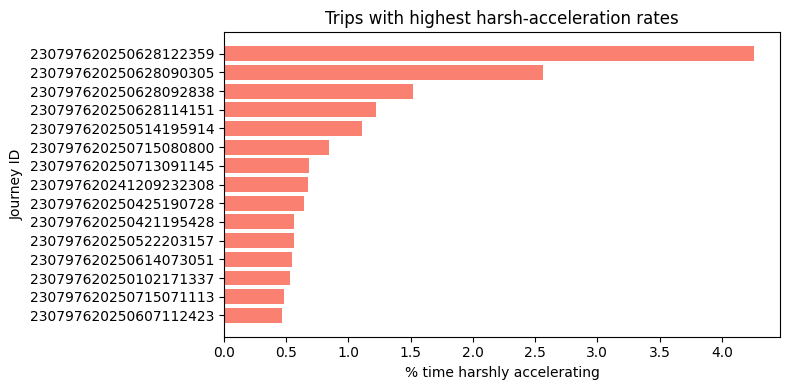

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.barh(
    rate_trip.sort_values("accel_rate", ascending=True).tail(15)["Journey ID"],
    rate_trip.sort_values("accel_rate", ascending=True).tail(15)["accel_rate"]*100,
    color="salmon"
)
plt.xlabel("% time harshly accelerating")
plt.ylabel("Journey ID")
plt.title("Trips with highest harsh-acceleration rates")
plt.tight_layout()
plt.show()

In [16]:
trip_duration = (
    df_1hz.groupby("Journey ID")["when"]
    .agg(start="min", stop="max")
    .reset_index()
)
trip_duration["duration_s"] = (trip_duration["stop"] - trip_duration["start"]).dt.total_seconds()
trip_duration["duration_min"] = trip_duration["duration_s"] / 60

In [17]:
trip_stats = rate_trip.merge(trip_duration, on="Journey ID", how="left")
trip_stats.head()

,Journey ID,accel_rate,brake_rate,start,stop,duration_s,duration_min
0,230797620241128161604,0.000000,0.000000,2024-11-28 16:16:04,2024-11-28 16:16:15,11.0,0.183333
1,230797620241128203502,0.000000,0.000476,2024-11-28 20:35:02,2024-11-28 21:10:26,2124.0,35.400000
2,230797620241128211313,0.000000,0.000898,2024-11-28 21:13:13,2024-11-28 21:31:48,1115.0,18.583333
3,230797620241129093202,0.000185,0.000000,2024-11-29 09:32:31,2024-11-29 11:02:42,5411.0,90.183333
4,230797620241129122442,0.000000,0.000000,2024-11-29 12:24:56,2024-11-29 12:33:46,530.0,8.833333


In [18]:
top_harsh_long = (
    trip_stats.sort_values(["accel_rate"], ascending=False)
              .loc[:, ["Journey ID","accel_rate","brake_rate","duration_min"]]
              .head(10)
)
top_harsh_long

,Journey ID,accel_rate,brake_rate,duration_min
1114,230797620250628122359,0.042553,0.000000,0.783333
1103,230797620250628090305,0.025641,0.019943,5.916667
1107,230797620250628092838,0.015152,0.025253,3.316667
1112,230797620250628114151,0.012232,0.021407,5.483333
871,230797620250514195914,0.011111,0.000000,1.500000
1266,230797620250715080800,0.008475,0.004237,3.983333
1251,230797620250713091145,0.006829,0.004268,100.100000
72,230797620241209232308,0.006711,0.000000,4.966667
766,230797620250425190728,0.006424,0.000000,7.833333
747,230797620250421195428,0.005650,0.000000,2.966667


In [19]:
trip_stats["harsh_accel_seconds"] = trip_stats["accel_rate"] * trip_stats["duration_s"]
trip_stats["harsh_brake_seconds"] = trip_stats["brake_rate"] * trip_stats["duration_s"]

trip_stats.sort_values("harsh_accel_seconds", ascending=False).head(10)

,Journey ID,accel_rate,brake_rate,start,stop,duration_s,duration_min,harsh_accel_seconds,harsh_brake_seconds
1251,230797620250713091145,0.006829,0.004268,2025-07-13 09:12:36,2025-07-13 10:52:42,6006.0,100.100000,41.017586,25.635991
1226,230797620250710171128,0.002696,0.002528,2025-07-10 17:12:06,2025-07-10 20:31:52,11986.0,199.766667,32.318166,30.298281
1223,230797620250710102135,0.002879,0.003071,2025-07-10 10:21:42,2025-07-10 13:16:06,10464.0,174.400000,30.129571,32.138209
1245,230797620250712193615,0.003555,0.003258,2025-07-12 19:39:24,2025-07-12 20:36:38,3434.0,57.233333,12.206161,11.188981
1058,230797620250614120057,0.001437,0.001568,2025-06-14 12:01:14,2025-06-14 14:09:55,7721.0,128.683333,11.094840,12.103462
1279,230797620250716070143,0.002662,0.003145,2025-07-16 07:01:52,2025-07-16 08:11:13,4161.0,69.350000,11.074522,13.088072
1103,230797620250628090305,0.025641,0.019943,2025-06-28 09:03:12,2025-06-28 09:09:07,355.0,5.916667,9.102564,7.079772
1362,230797620250725190144,0.001813,0.002947,2025-07-25 19:01:57,2025-07-25 20:17:28,4531.0,75.516667,8.215775,13.350635
663,230797620250330132541,0.001202,0.001716,2025-03-30 13:26:10,2025-03-30 15:04:29,5899.0,98.316667,7.087710,10.125300
1345,230797620250723150726,0.004013,0.004013,2025-07-23 15:10:05,2025-07-23 15:37:10,1625.0,27.083333,6.521739,6.521739


In [20]:
trip_id = "230797620250628122359"

subset = (
    df_1hz[df_1hz["Journey ID"] == trip_id]
    .sort_values("when")
    .copy()
)
print("Rows:", len(subset))
subset.head(3)

Rows: 47


,EventTimestamp,GpsSpeedMph,GpsSpeed,RoadSpeedLimitMph,Latitude,Longitude,Journey ID,source_sheet,when,speed,limit,accel,harsh_accel,harsh_brake
990108,2025-06-28 12:24:13,3.728,6.0,30.0,53.791279,-1.78243,230797620250628122359,Journey Event 1Hz - Part 2,2025-06-28 12:24:13,3.728,30.0,NaN,False,False
990109,2025-06-28 12:24:14,3.728,6.0,30.0,53.791248,-1.78246,230797620250628122359,Journey Event 1Hz - Part 2,2025-06-28 12:24:14,3.728,30.0,0.0,False,False
990110,2025-06-28 12:24:16,3.728,6.0,30.0,53.791061,-1.78259,230797620250628122359,Journey Event 1Hz - Part 2,2025-06-28 12:24:16,3.728,30.0,0.0,False,False


In [21]:
subset["accel"] = (
    subset["speed"].diff() /
    subset["when"].diff().dt.total_seconds()
)
subset["harsh_accel"] = subset["accel"] > 6.7
subset["harsh_brake"] = subset["accel"] < -6.7

In [22]:
import folium

m = folium.Map(
    location=[subset["Latitude"].mean(), subset["Longitude"].mean()],
    zoom_start=12, tiles="cartodbpositron"
)

# Draw full route
folium.PolyLine(
    subset[["Latitude","Longitude"]].dropna().values,
    color="gray", weight=2, opacity=0.6
).add_to(m)

# Add harsh acceleration points
for _, row in subset[subset["harsh_accel"]].iterrows():
    folium.CircleMarker(
        location=(row["Latitude"], row["Longitude"]),
        radius=4,
        color="red", fill=True, fill_opacity=0.8,
        popup=f"Accel +{row['accel']:.2f} mph/s<br>{row['when']}"
    ).add_to(m)

# Add harsh braking points
for _, row in subset[subset["harsh_brake"]].iterrows():
    folium.CircleMarker(
        location=(row["Latitude"], row["Longitude"]),
        radius=4,
        color="blue", fill=True, fill_opacity=0.8,
        popup=f"Brake {row['accel']:.2f} mph/s<br>{row['when']}"
    ).add_to(m)

m.save("outputs/harsh_events_map.html")
print("✓ Map saved → outputs/harsh_events_map.html")

✓ Map saved → outputs/harsh_events_map.html


/Users/abdulrahmanaboluhom/Documents/GitHub/Projects/indepth-driving-data-analysis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## C. Maps

## D. Findings